## Análise do Dataset - Descrição

📌 Identificação (não usado no modelo)<br><br>


`id` – identificador da linha no dataset (apenas referência interna, não representa uma informação do cliente)

`id_cliente` – número de identificação único do cliente no banco

`sobrenome` – sobrenome do cliente

<br><br> 💳 Perfil financeiro e relacionamento<br><br>

`score_credito` – pontuação de crédito do cliente, indicando seu histórico e confiabilidade financeira

`saldo` – saldo atual da conta bancária do cliente

`salario_estimado` – estimativa de renda anual do cliente

`num_produtos` – quantidade de produtos financeiros que o cliente possui no banco (conta, cartão, empréstimo, etc.)


<br><br>👤 Perfil demográfico<br><br>


`pais` – país de residência do cliente (por exemplo: França, Espanha, Alemanha)

`genero` – gênero do cliente

`idade` – idade do cliente em anos


<br><br>⏳ Relacionamento com o banco<br><br>


`tempo_relacionamento` – número de anos que o cliente mantém relacionamento com o banco

`membro_ativo` – indica se o cliente é considerado ativo pelo banco

- 0 = não ativo

- 1 = ativo


`possui_cartao_credito` – indica se o cliente possui cartão de crédito

- 0 = não

- 1 = sim


<br><br>🎯 Variável alvo<br><br>


`churned` – variável alvo do modelo

- 0 = cliente permanece no banco

- 1 = cliente saiu do banco


### Importação bibliotecas

In [1]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 3.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from feature_engine import encoding, discretisation, outliers, transformation

import joblib


### Carregamento do Dataset

In [3]:

# URL do CSV (dataset)
url = "https://raw.githubusercontent.com/hackathon-ficaAi/churnInsight/refs/heads/main/data/churn_treino.csv"
df = pd.read_csv(url)

### Validação e entedimento dos dados

In [4]:
df.head()

,id,id_cliente,sobrenome,score_credito,pais,genero,idade,tempo_relacionamento,saldo,num_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churned
0,0,15674932,Okwudilichukwu,668,frança,masculino,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,frança,masculino,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,frança,masculino,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,frança,masculino,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,espanha,masculino,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [5]:
df.shape

(165034, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     165034 non-null  int64  
 1   id_cliente             165034 non-null  int64  
 2   sobrenome              165034 non-null  object 
 3   score_credito          165034 non-null  int64  
 4   pais                   165034 non-null  object 
 5   genero                 165034 non-null  object 
 6   idade                  165034 non-null  float64
 7   tempo_relacionamento   165034 non-null  int64  
 8   saldo                  165034 non-null  float64
 9   num_produtos           165034 non-null  int64  
 10  possui_cartao_credito  165034 non-null  float64
 11  membro_ativo           165034 non-null  float64
 12  salario_estimado       165034 non-null  float64
 13  churned                165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
m

In [7]:
(df.isnull().sum())

,0
id,0
id_cliente,0
sobrenome,0
score_credito,0
pais,0
genero,0
idade,0
tempo_relacionamento,0
saldo,0
num_produtos,0


In [8]:
(df.duplicated().sum())

np.int64(0)

In [9]:
df.describe()

,id,id_cliente,score_credito,idade,tempo_relacionamento,saldo,num_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churned
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [10]:
categoricas = df.select_dtypes(include=['object']).copy()
categoricas.describe()

,sobrenome,pais,genero
count,165034,165034,165034
unique,2797,3,2
top,Hsia,frança,masculino
freq,2456,94215,93150


### Análise Exploratória dos Dados (EDA)

In [11]:
df['churned'].value_counts()

,count
churned,
0,130113
1,34921


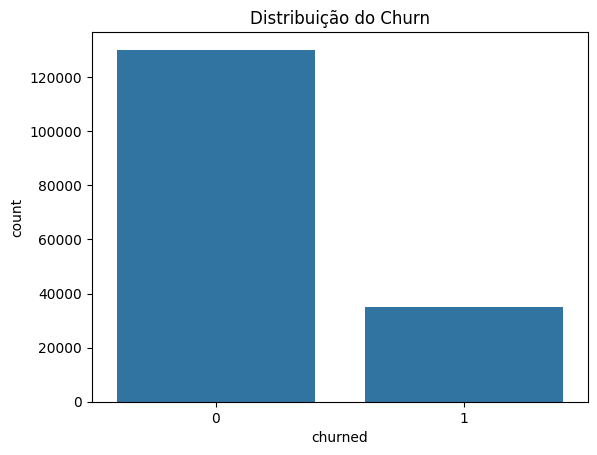

In [12]:
sns.countplot(data=df, x='churned')
plt.title('Distribuição do Churn')
plt.show()

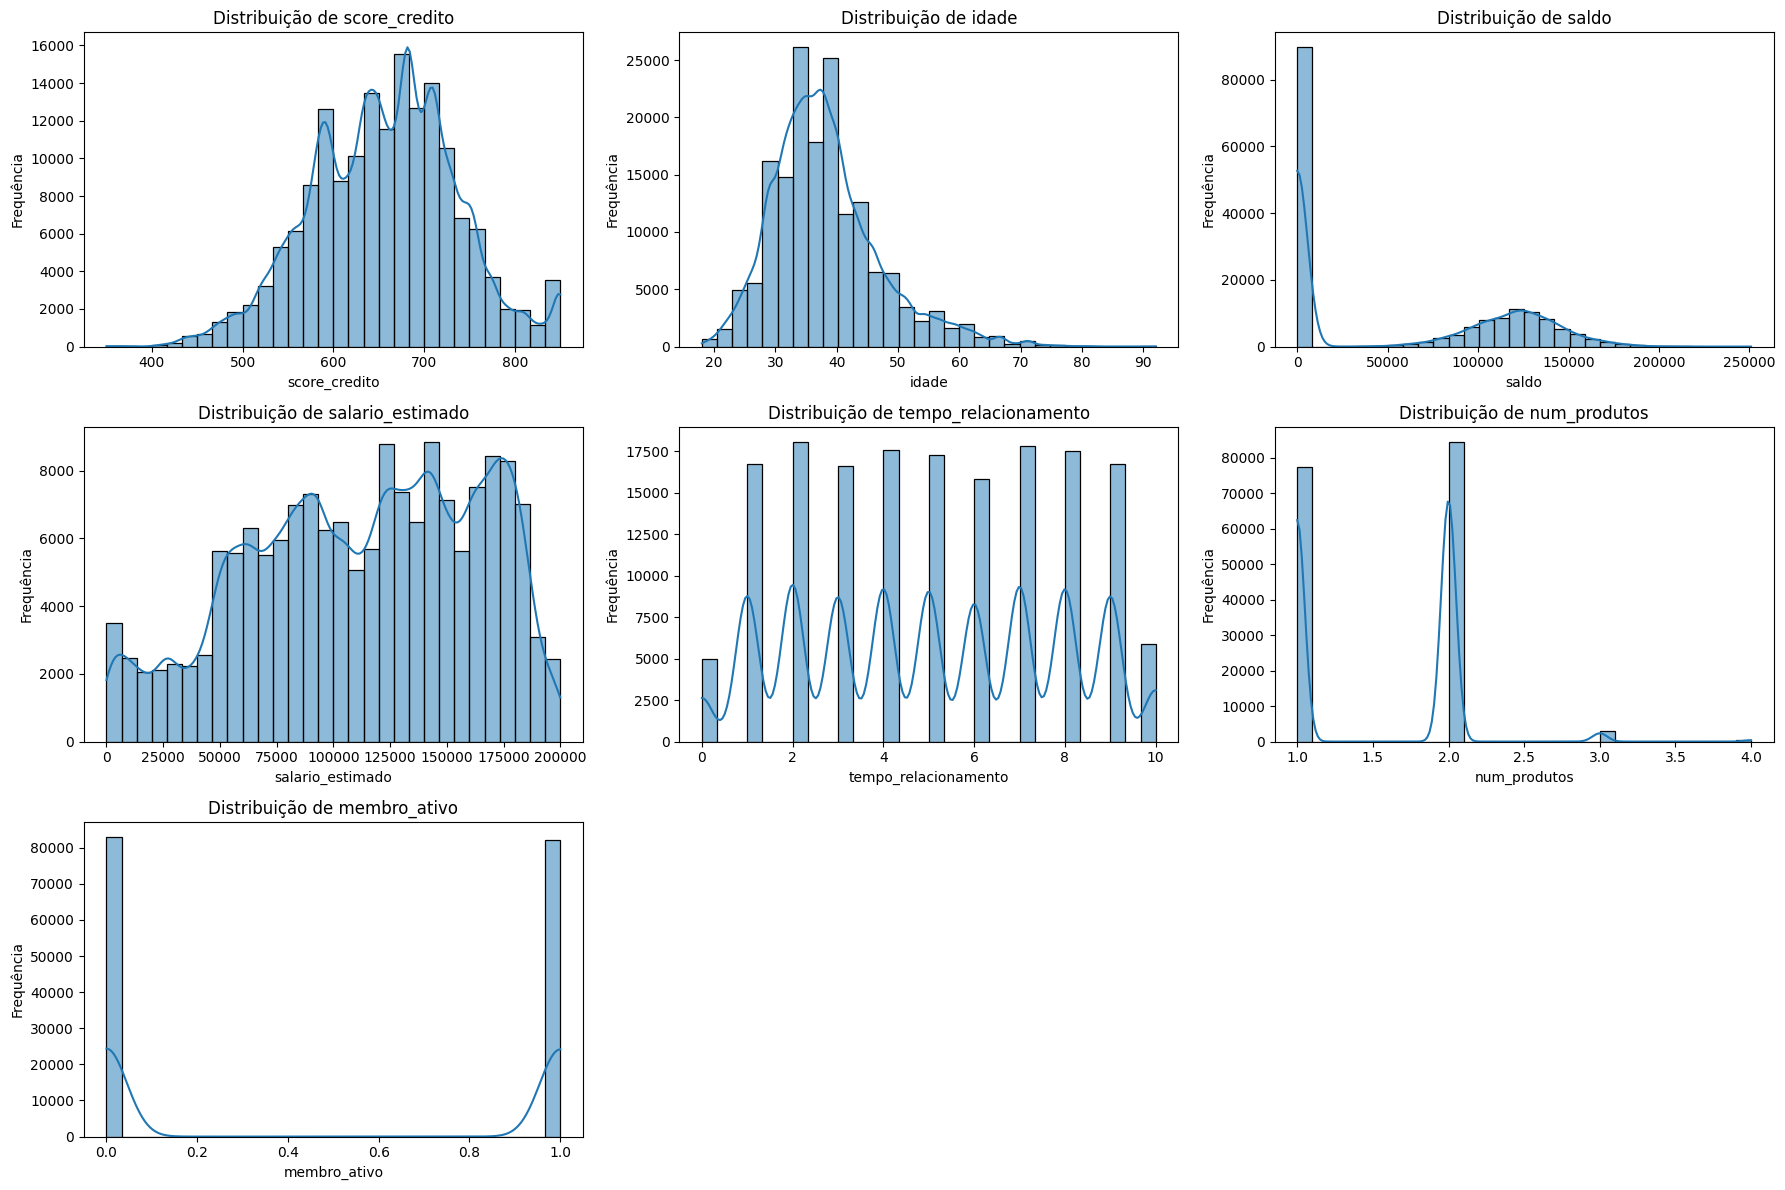

In [13]:
colunas_numericas = [
    'score_credito',
    'idade',
    'saldo',
    'salario_estimado',
    'tempo_relacionamento',
    'num_produtos',
    'membro_ativo'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

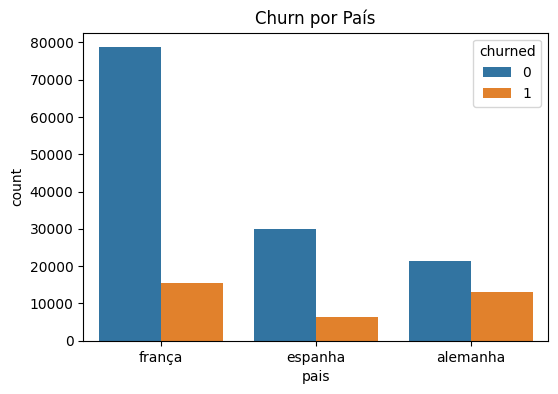

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='pais', hue='churned')
plt.title('Churn por País')
plt.show()

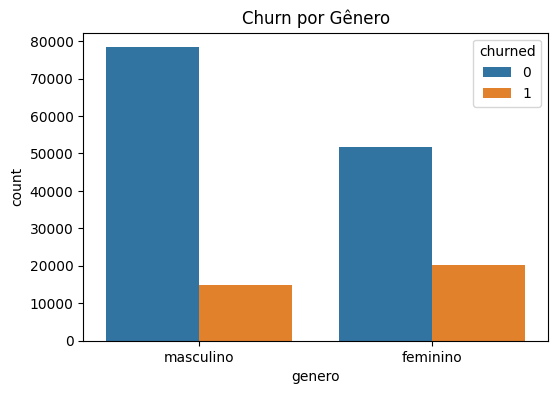

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='genero', hue='churned')
plt.title('Churn por Gênero')
plt.show()


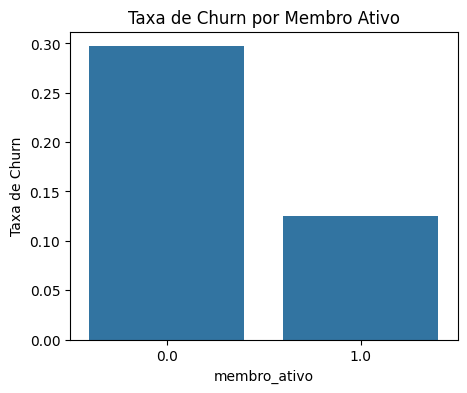

In [16]:
churn_ativo = (
    df
    .groupby('membro_ativo')['churned']
    .mean()
    .reset_index()
)

plt.figure(figsize=(5,4))
sns.barplot(data=churn_ativo, x='membro_ativo', y='churned')
plt.title('Taxa de Churn por Membro Ativo')
plt.ylabel('Taxa de Churn')
plt.show()

num_produtos
3    0.882516
4    0.875789
1    0.347119
2    0.060422
Name: churned, dtype: float64


/tmp/ipython-input-2595837396.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_por_produtos.index, y=taxa_por_produtos.values, palette="magma")


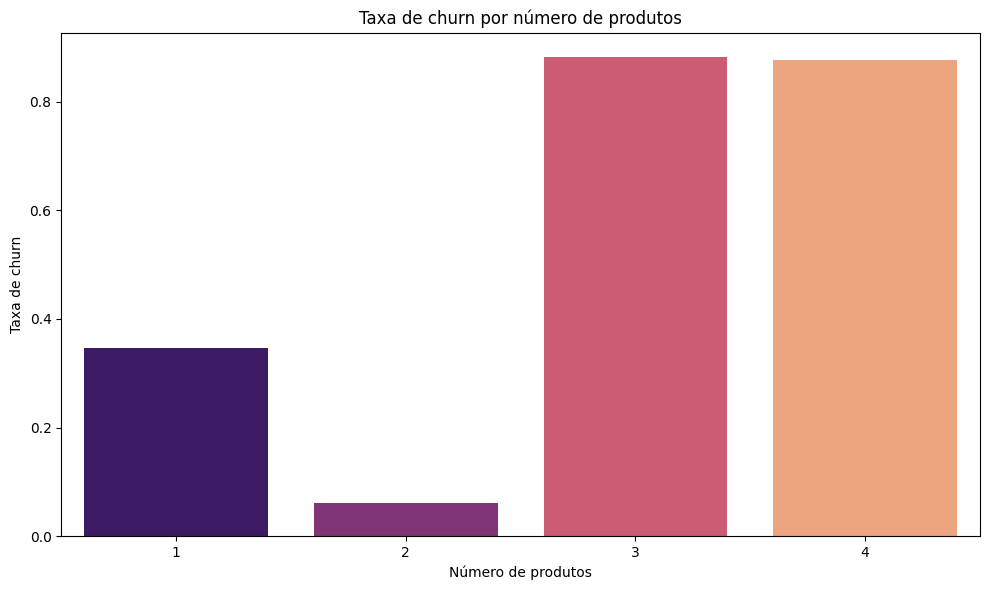

In [17]:
# Taxa de churn por número de produtos
taxa_por_produtos = df.groupby('num_produtos')['churned'].mean().sort_values(ascending=False)
print(taxa_por_produtos)

# Gráfico de taxa (não contagem)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=taxa_por_produtos.index, y=taxa_por_produtos.values, palette="magma")
plt.title("Taxa de churn por número de produtos")
plt.xlabel("Número de produtos")
plt.ylabel("Taxa de churn")
plt.tight_layout()
plt.show()

Taxa de churn por tempo de relacionamento e gênero:
genero                feminino  masculino
tempo_relacionamento                     
0                     0.329656   0.192995
1                     0.298210   0.169508
2                     0.258853   0.144609
3                     0.302024   0.170499
4                     0.293948   0.174600
5                     0.290296   0.167141
6                     0.258050   0.153365
7                     0.249091   0.140752
8                     0.267127   0.145775
9                     0.281494   0.159866
10                    0.290621   0.151899


/tmp/ipython-input-3684180027.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  grafico = sns.catplot(


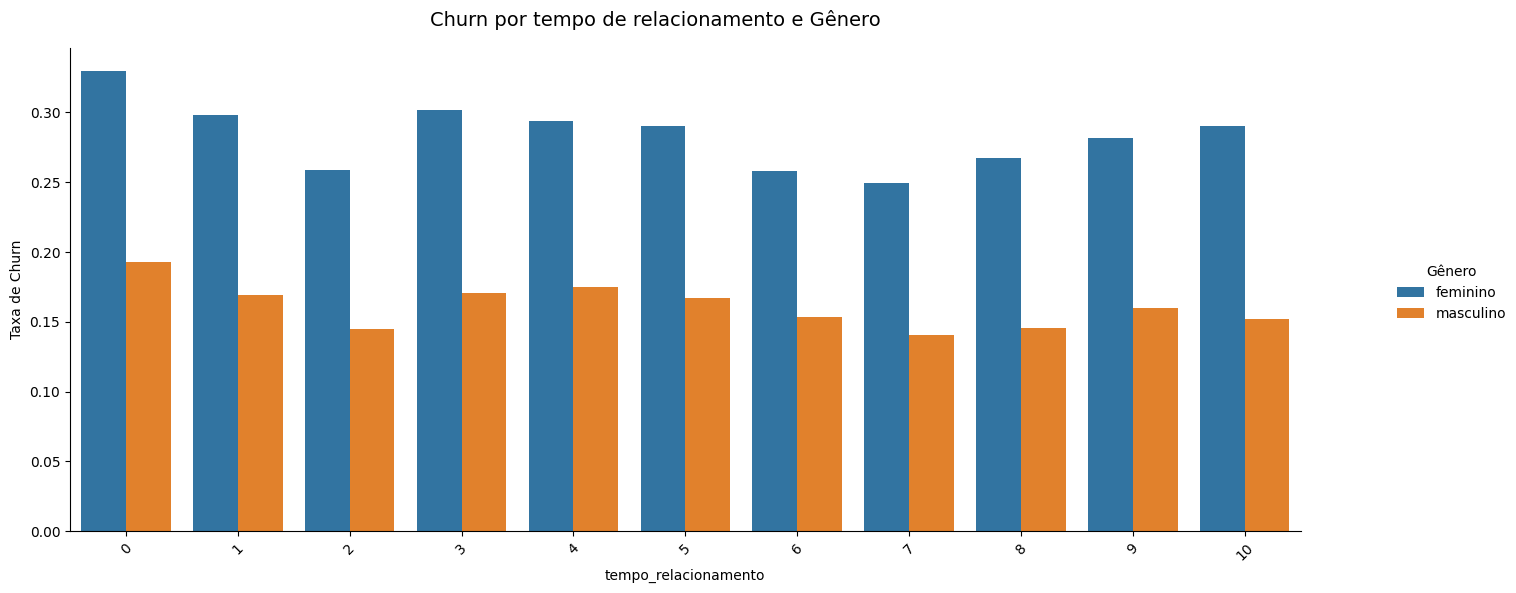

In [18]:
# Tabela cruzada: churn por faixa de tempo e gênero
tabela_genero = pd.crosstab(df['tempo_relacionamento'], df['genero'],
                            values=df['churned'], aggfunc='mean')

print("Taxa de churn por tempo de relacionamento e gênero:")
print(tabela_genero)

# Visualização
# Visualização ajustada
grafico = sns.catplot(
    x="tempo_relacionamento", y="churned", hue="genero",
    kind="bar", data=df, ci=None,
    height=6, aspect=2   # aumenta largura (aspect define proporção)
)

# Ajustar título e eixos
grafico.fig.suptitle("Churn por tempo de relacionamento e Gênero", fontsize=14)
grafico.set_axis_labels("tempo_relacionamento", "Taxa de Churn")
grafico.set_xticklabels(rotation=45)

# Ajustar legenda
grafico._legend.set_title("Gênero")
grafico._legend.set_bbox_to_anchor((1.15, 0.5))  # move para fora, à direita
grafico._legend.set_frame_on(False)              # remove borda da legenda

plt.tight_layout()
plt.show()

Taxa de churn por faixa etária e país:
pais         alemanha   espanha    frança
faixa_idade                              
18–30        0.156835  0.071131  0.065307
31–40        0.235132  0.099062  0.093284
41–50        0.565178  0.321878  0.323111
51–60        0.762151  0.513962  0.549232
60+          0.503521  0.272336  0.259508


/tmp/ipython-input-543057060.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  grafico = sns.catplot(


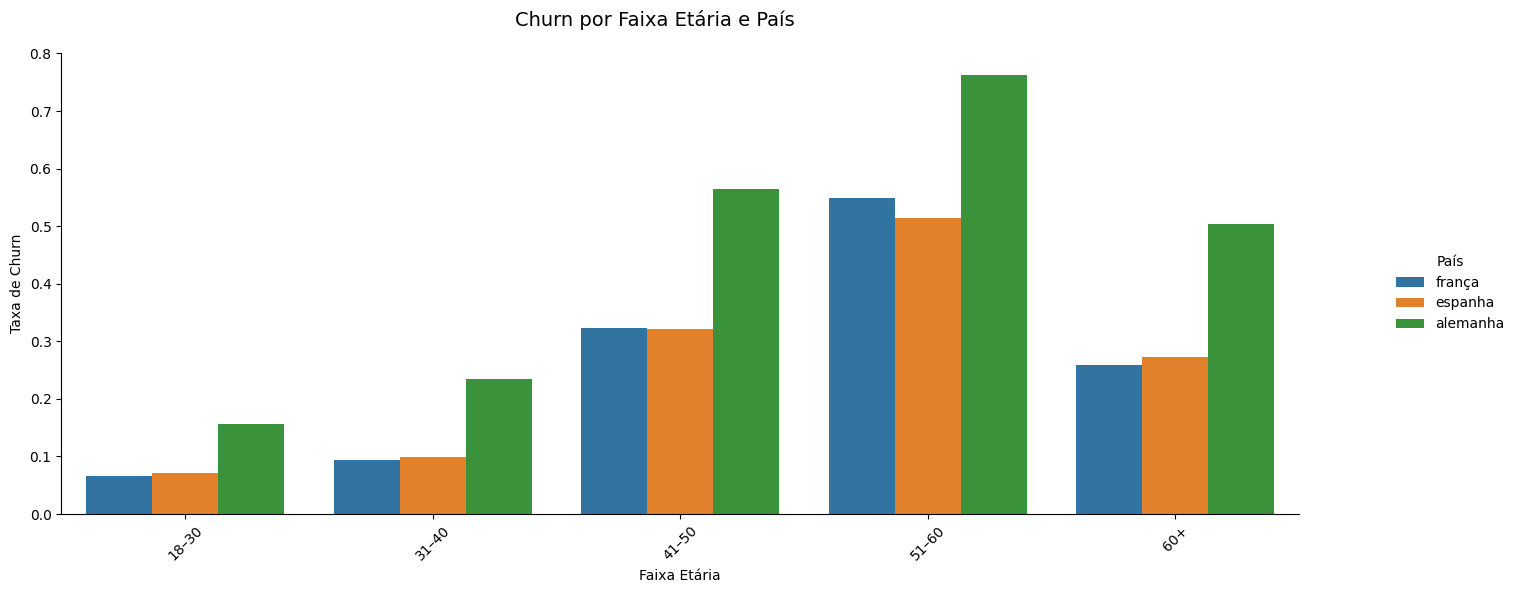

In [19]:
df_eda = df.copy()

df_eda['faixa_idade'] = pd.cut(
    df_eda['idade'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18–30', '31–40', '41–50', '51–60', '60+']
)
tabela_pais = pd.crosstab(
    df_eda['faixa_idade'],
    df_eda['pais'],
    values=df_eda['churned'],
    aggfunc='mean'
)

print("Taxa de churn por faixa etária e país:")
print(tabela_pais)
grafico = sns.catplot(
    x='faixa_idade',
    y='churned',
    hue='pais',
    kind='bar',
    data=df_eda,
    ci=None,
    height=6,
    aspect=2
)

# Título e eixos
grafico.fig.suptitle("Churn por Faixa Etária e País", fontsize=14)
grafico.set_axis_labels("Faixa Etária", "Taxa de Churn")
grafico.set_xticklabels(rotation=45)

# Legenda
grafico._legend.set_title("País")
grafico._legend.set_bbox_to_anchor((1.15, 0.5))
grafico._legend.set_frame_on(False)

plt.tight_layout()
plt.show()

Criar campanhas de retenção exclusivas para clientes alemães. País deve ser incluído como feature importante no modelo preditivo.

Pode ser útil criar uma variável binária: risco_alto = pais == 'alemanha'.

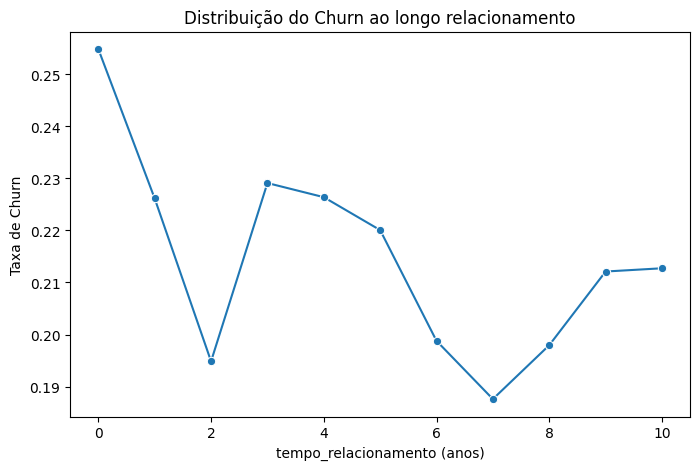

In [20]:
churn_tempo_relacionamento = (
    df
    .groupby('tempo_relacionamento')['churned']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=churn_tempo_relacionamento, x='tempo_relacionamento', y='churned', marker='o')
plt.title('Distribuição do Churn ao longo relacionamento')
plt.xlabel('tempo_relacionamento (anos)')
plt.ylabel('Taxa de Churn')
plt.show()

O churn é concentrado nos clientes novos — os primeiros 12 meses são críticos

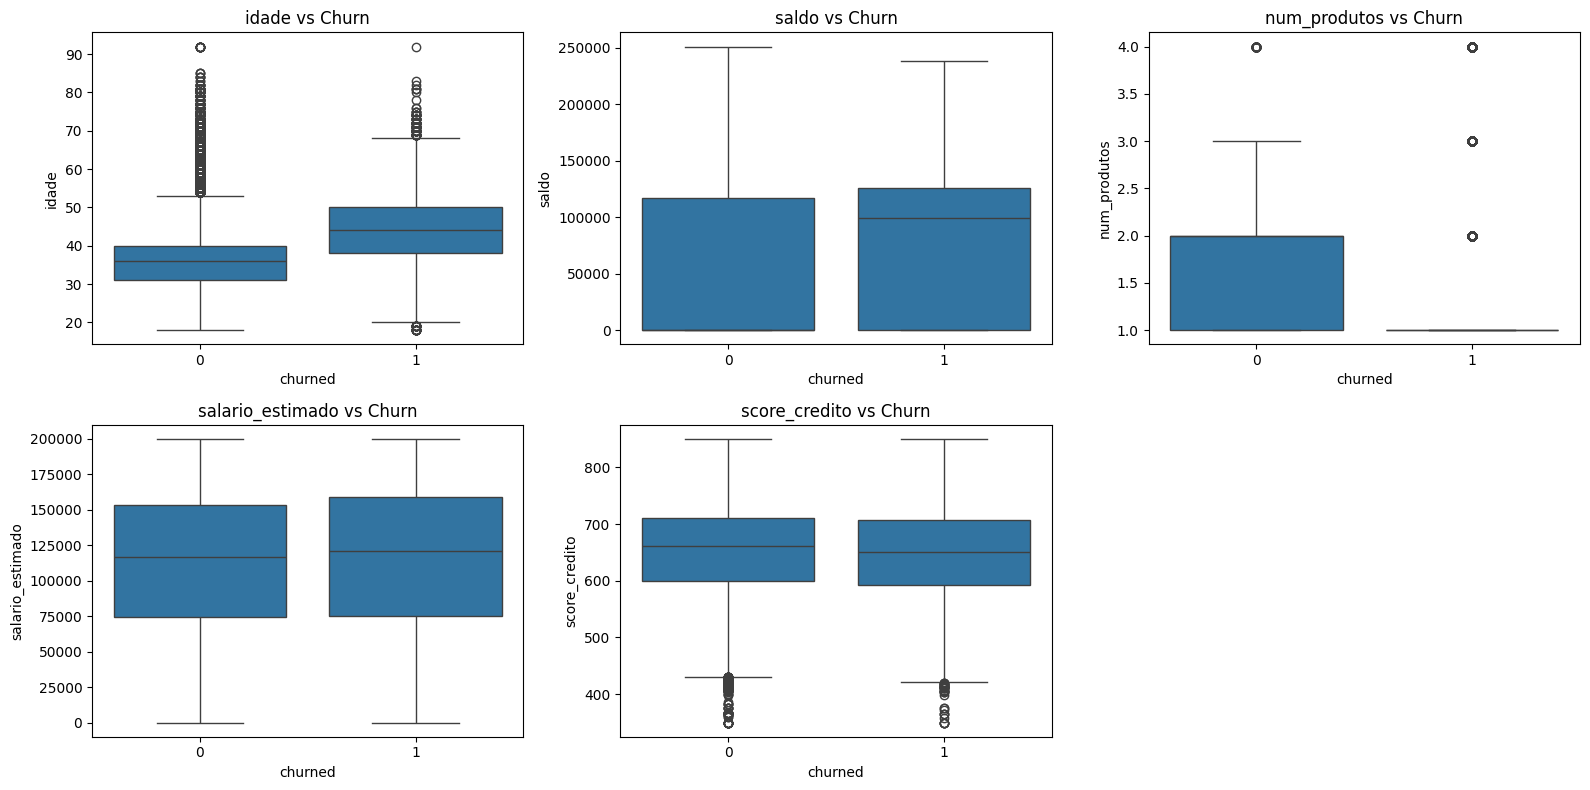

In [21]:
colunas_boxplot = [
    'idade',
    'saldo',
    'num_produtos',
    'salario_estimado',
    'score_credito'
]

plt.figure(figsize=(16, 8))

for i, col in enumerate(colunas_boxplot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='churned', y=col)
    plt.title(f'{col} vs Churn')
    plt.xlabel('churned')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

1. idade vs churned
Clientes que churnaram tendem a ser mais velhos.

A mediana da idade é visivelmente maior no grupo churned.

2. saldo vs churned
Churn parece mais comum entre clientes com saldo mais alto, o que pode indicar falta de engajamento mesmo com recursos disponíveis.

3. num_produtos vs churned
Clientes com menos produtos têm maior churn.

Aqueles com mais produtos (2 ou mais) tendem a permanecer.

4. score_credito,
Essa variável têm pouca diferença visual entre os grupos — podem ter menor poder preditivo isoladamente.

5. salario_estimado,
Essa variável têm pouca diferença visual entre os grupos — podem ter menor poder preditivo isoladamente.

**Análise quantitativa de outliers (método IQR)**

In [22]:
colunas_outliers = [
    'idade',
    'saldo',
    'num_produtos',
    'score_credito',
    'salario_estimado'
]

resumo_outliers = []

for col in colunas_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = df[
        (df[col] < limite_inferior) | (df[col] > limite_superior)
    ].shape[0]

    perc_outliers = qtd_outliers / df.shape[0] * 100

    resumo_outliers.append({
        'Variável': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior,
        'Qtd Outliers': qtd_outliers,
        '% Outliers': perc_outliers
    })

df_outliers = pd.DataFrame(resumo_outliers)

df_outliers

,Variável,Q1,Q3,IQR,Limite Inferior,Limite Superior,Qtd Outliers,% Outliers
0,idade,32.00,42.0000,10.0000,17.00000,57.00000,6394,3.874353
1,saldo,0.00,119939.5175,119939.5175,-179909.27625,299848.79375,0,0.000000
2,num_produtos,1.00,2.0000,1.0000,-0.50000,3.50000,475,0.287819
3,score_credito,597.00,710.0000,113.0000,427.50000,879.50000,253,0.153302
4,salario_estimado,74637.57,155152.4675,80514.8975,-46134.77625,275924.81375,0,0.000000


Investigar se os outliers de cada variável têm maior taxa de churn.

In [23]:
# Variáveis numéricas contínuas adequadas para IQR
variaveis_outliers = [
    'idade',
    'saldo',
    'num_produtos',
    'score_credito',
    'salario_estimado'

]

# Função: analisar churn entre outliers e não-outliers
def analisar_outliers_churn(df, col, target='churned'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Identificar outliers
    is_outlier = (df[col] < limite_inf) | (df[col] > limite_sup)

    # Taxas de churn
    churn_outliers = df.loc[is_outlier, target].mean()
    churn_normal = df.loc[~is_outlier, target].mean()

    return {
        "Variável": col,
        "Qtd Outliers": is_outlier.sum(),
        "% Outliers": is_outlier.mean() * 100,
        "Taxa Churn Outliers (%)": churn_outliers * 100,
        "Taxa Churn Normal (%)": churn_normal * 100,
        "Diferença (p.p.)": (churn_outliers - churn_normal) * 100,
        "Risco Relativo": (churn_outliers / churn_normal) if churn_normal > 0 else np.nan
    }

# Executar análise
resultados = []
for col in variaveis_outliers:
    resultados.append(analisar_outliers_churn(df, col))

df_analise_outliers = pd.DataFrame(resultados)

# Organizar melhor a visualização
df_analise_outliers = df_analise_outliers.sort_values(
    by="Diferença (p.p.)",
    ascending=False
)

print("=== PERFIL DE CHURN: OUTLIERS vs NÃO-OUTLIERS (IQR) ===\n")
display(df_analise_outliers.round(2))


=== PERFIL DE CHURN: OUTLIERS vs NÃO-OUTLIERS (IQR) ===



,Variável,Qtd Outliers,% Outliers,Taxa Churn Outliers (%),Taxa Churn Normal (%),Diferença (p.p.),Risco Relativo
2,num_produtos,475,0.29,87.58,20.97,66.61,4.18
0,idade,6394,3.87,38.38,20.47,17.91,1.88
3,score_credito,253,0.15,22.53,21.16,1.37,1.06
1,saldo,0,0.00,NaN,21.16,NaN,NaN
4,salario_estimado,0,0.00,NaN,21.16,NaN,NaN


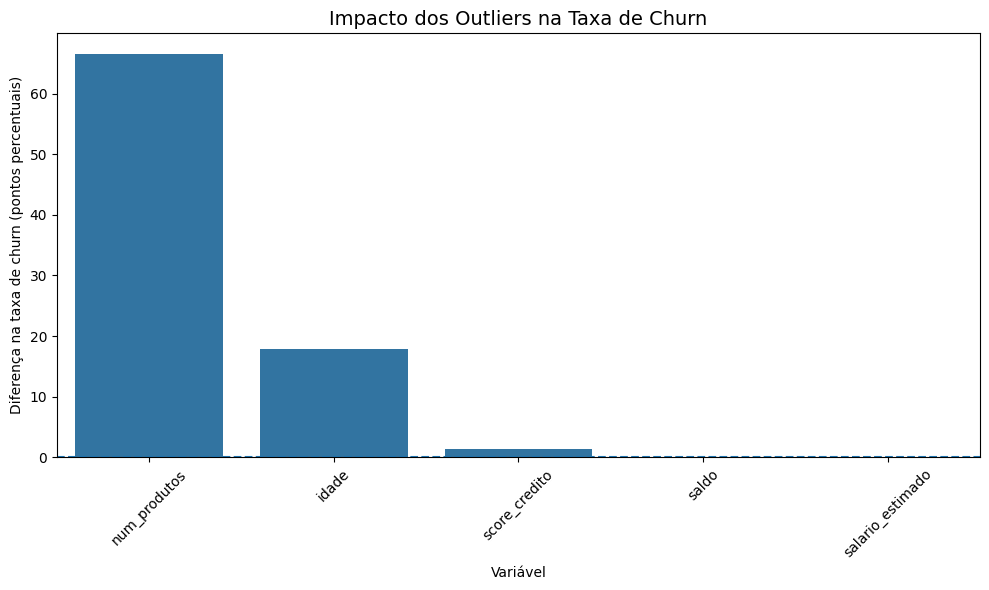

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Variável",
    y="Diferença (p.p.)",
    data=df_analise_outliers
)

# Linha de referência (sem impacto)
plt.axhline(0, linestyle="--")

plt.title("Impacto dos Outliers na Taxa de Churn", fontsize=14)
plt.ylabel("Diferença na taxa de churn (pontos percentuais)")
plt.xlabel("Variável")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

idade: outliers (muito jovens ou muito velhos) têm 17,9% mais churn que os demais.

Criar variáveis binárias indicando se o cliente é outlier em idade ou num_produtos.

Focar em clientes com perfis extremos nessas variáveis para ações de retenção.

Usar essas variáveis como features importantes no modelo preditivo de churn.

/tmp/ipython-input-4229840370.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_faixa_produtos = df.groupby(['faixa_idade','num_produtos'])['churned'].mean().unstack()


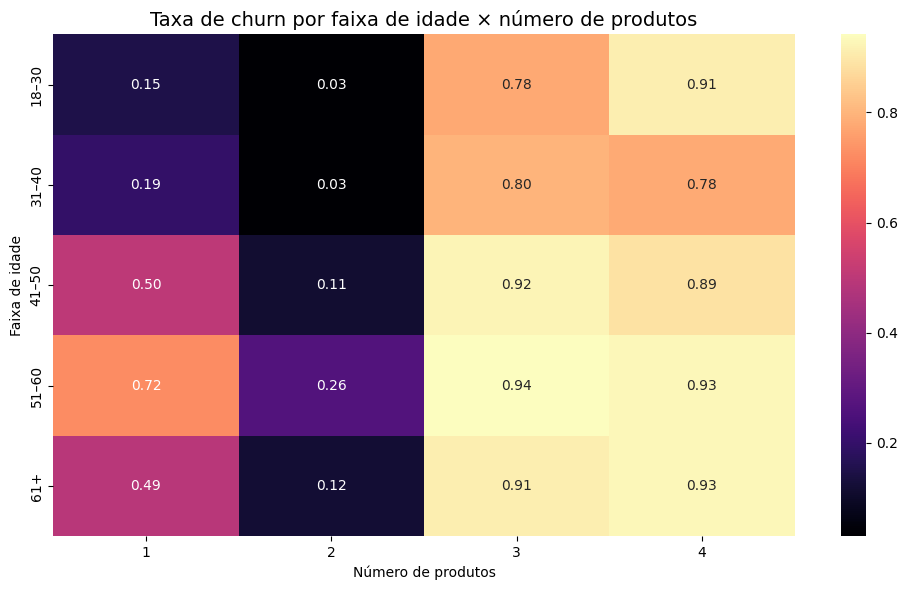

In [25]:

# 1. Criar faixas de idade
bins = [18, 30, 40, 50, 60, 100]
labels = ['18–30', '31–40', '41–50', '51–60', '61+']
df['faixa_idade'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

# 2. Calcular taxa de churn por faixa de idade e número de produtos
taxa_faixa_produtos = df.groupby(['faixa_idade','num_produtos'])['churned'].mean().unstack()

# 3. Plotar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(taxa_faixa_produtos, cmap="magma", annot=True, fmt=".2f")
plt.title("Taxa de churn por faixa de idade × número de produtos", fontsize=14)
plt.xlabel("Número de produtos")
plt.ylabel("Faixa de idade")
plt.tight_layout()
plt.show()

In [26]:
df.drop(columns=['faixa_idade'], inplace=True)

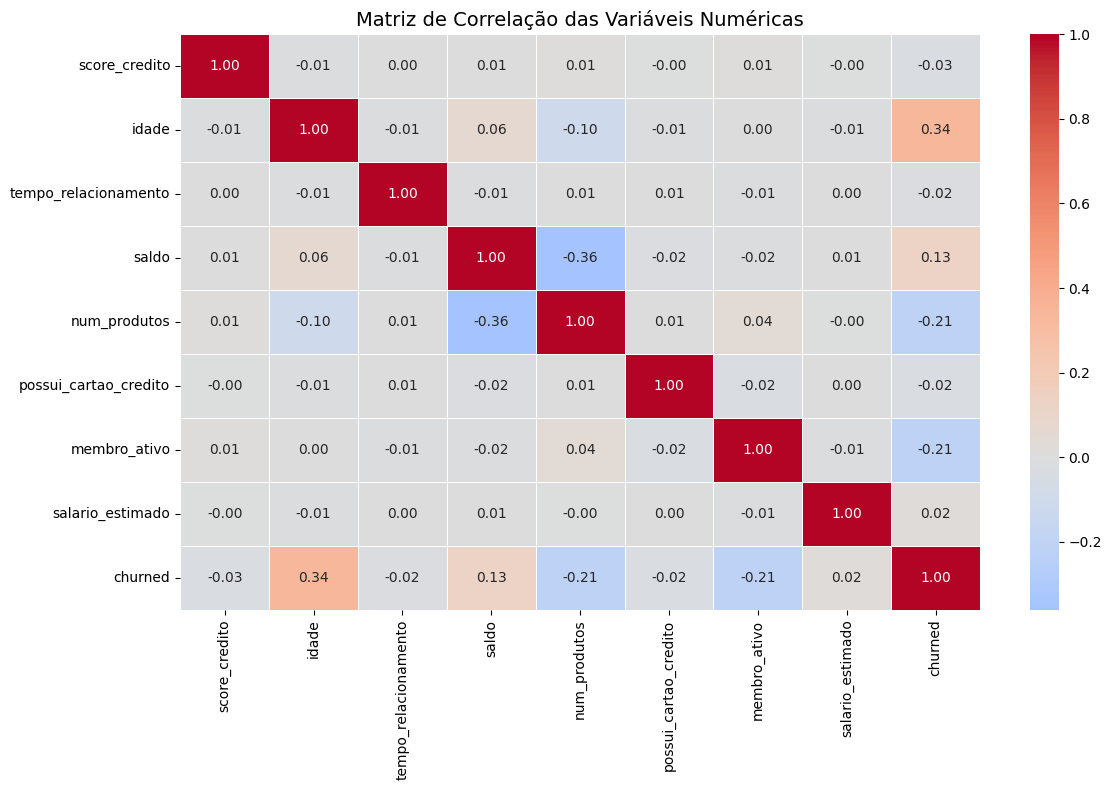

In [27]:
# Selecionar variáveis numéricas (exceto IDs)
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
cols_numericas = cols_numericas.drop(['id', 'id_cliente'], errors='ignore')

corr = df[cols_numericas].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.show()


Idade é o fator numérico mais correlacionado com churn — pode indicar que clientes mais velhos estão mais propensos a sair.

Engajamento com produtos e serviços (número de produtos e status de membro ativo) são protetores contra churn.

Tempo de relacionamento também é um bom indicador: quanto mais tempo, menor a chance de churn.

### Tratamento do Dados

In [28]:
df = df.drop(columns=['id', 'id_cliente', 'sobrenome'], errors='ignore')

In [29]:
df.columns

Index(['score_credito', 'pais', 'genero', 'idade', 'tempo_relacionamento',
       'saldo', 'num_produtos', 'possui_cartao_credito', 'membro_ativo',
       'salario_estimado', 'churned'],
      dtype='object')

### Pré-processamento

In [30]:
y = df['churned']
X = df.drop(columns='churned')

In [31]:
categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()
numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categóricas:", categoricas)
print("Numéricas:", numericas)

Categóricas: ['pais', 'genero']
Numéricas: ['score_credito', 'idade', 'tempo_relacionamento', 'saldo', 'num_produtos', 'possui_cartao_credito', 'membro_ativo', 'salario_estimado']


In [32]:
X_encoded = pd.get_dummies(
    X,
    columns=categoricas,
    drop_first=True
)

In [33]:
X_encoded.head()
X_encoded.shape

(165034, 11)

### Primeira Modelagem (Baseline)


===== Logistic Regression =====
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90     26023
           1       0.69      0.38      0.49      6984

    accuracy                           0.83     33007
   macro avg       0.77      0.67      0.70     33007
weighted avg       0.82      0.83      0.81     33007



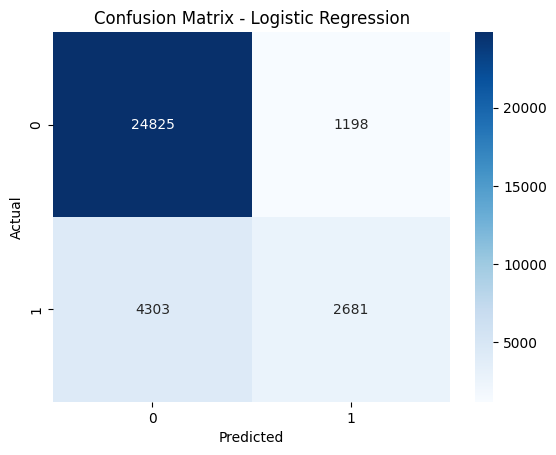

ROC-AUC: 0.8137

===== Decision Tree =====
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87     26023
           1       0.52      0.54      0.53      6984

    accuracy                           0.80     33007
   macro avg       0.70      0.70      0.70     33007
weighted avg       0.80      0.80      0.80     33007



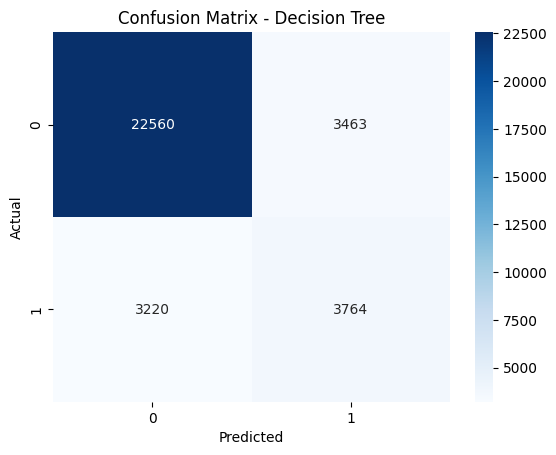

ROC-AUC: 0.7032

===== Random Forest =====
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     26023
           1       0.72      0.53      0.61      6984

    accuracy                           0.86     33007
   macro avg       0.80      0.74      0.76     33007
weighted avg       0.85      0.86      0.85     33007



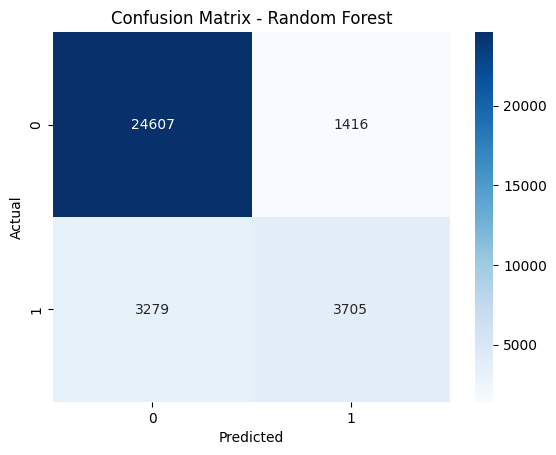

ROC-AUC: 0.8716


In [34]:
# Separar treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Definir modelos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Treinar e avaliar cada modelo
for nome, modelo in modelos.items():
    print(f"\n===== {nome} =====")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_val)
    y_prob = modelo.predict_proba(X_val)[:, 1] if hasattr(modelo, "predict_proba") else None

    # Classification report
    print("Classification Report:\n", classification_report(y_val, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {nome}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC-AUC
    if y_prob is not None:
        roc = roc_auc_score(y_val, y_prob)
        print(f"ROC-AUC: {roc:.4f}")

# Modelagem Final

Para garantir um modelo mais robusto foi inicialmente criado um Transformador, nele são feitas modificações personalizadas de variáveis para criação de novas colunas, servindo como nossa feature engineering inicial. Foi colocado dentro de um objeto para que possa ser utilizado dentro da Pipeline de transformação.

In [35]:
from sklearn import model_selection, tree, linear_model, naive_bayes, ensemble, metrics, pipeline

In [36]:
# Criando uma Classe de transformação de features para passar na pipeline
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, pais_col='pais', genero_col='genero'):
        self.pais_col = pais_col
        self.genero_col = genero_col
        self.le_pais = LabelEncoder()
        self.le_genero = LabelEncoder()

    def fit(self, X, y=None):
        if not hasattr(X, 'columns'):
            raise ValueError("X precisa ser um pandas DataFrame")

        X = X.copy()
        self.feature_names_in_ = np.array(X.columns)

        # Fit encoders
        self.le_pais.fit(X[self.pais_col].astype(str))
        self.le_genero.fit(X[self.genero_col].astype(str))

        # Montar lista de features de saída
        output = list(X.columns).copy()

        # Features críticas para recall de churn
        output += ['saldo_zero']  # com 0 saldos
        output += ['baixo_engajamento']  # poucos produtos + inativo
        output += ['produto_unico']  # menor vínculo
        output += ['produtos_excessivos']  # sobrecarga (3-4 produtos)
        output += ['alemanha_flag']  # país com maior churn
        output += ['saldo_por_produto']  # rentabilidade
        output += ['saldo_salario_ratio']  # capacidade de poupança
        output += ['inativo_sem_saldo']  # inativos sem saldo
        output += ['idade_produtos_interacao']  # interação entre idade e qtd produtos

        self._output_features = output
        return self

    def transform(self, X):
        if not hasattr(self, 'feature_names_in_'):
            raise RuntimeError("Chame fit(X) antes de transform(X)")

        X = X.copy()

        # Encodings básicos (necessários para flags)
        X[self.pais_col] = X[self.pais_col].astype(str)
        X[self.genero_col] = X[self.genero_col].astype(str)

        # 1. Saldo zero
        if 'saldo' in X.columns:
            X['saldo_zero'] = (X['saldo'] == 0).astype(int)

        # 2. Baixo engajamento: 1 produto ou menos + inativo
        if 'num_produtos' in X.columns and 'membro_ativo' in X.columns:
            X['baixo_engajamento'] = (
                (X['num_produtos'] <= 1) & (X['membro_ativo'] == 0)
            ).astype(int)

        # 3. Produto único
        if 'num_produtos' in X.columns:
            X['produto_unico'] = (X['num_produtos'] == 1).astype(int)
            X['produtos_excessivos'] = (X['num_produtos'] >= 3).astype(int)

        # 4. Alemanha (ajuste o nome conforme dataset: 'alemanha', 'Germany', etc)
        try:
            alemanha_code = self.le_pais.transform(['alemanha'])[0]
            X['alemanha_flag'] = (X[self.pais_col].astype(str) == 'alemanha').astype(int)
        except:
            try:
                X['alemanha_flag'] = (X[self.pais_col].astype(str) == 'Germany').astype(int)
            except:
                X['alemanha_flag'] = 0

        # 5. Saldo por produto - valor médio por relacionamento
        if 'saldo' in X.columns and 'num_produtos' in X.columns:
            X['saldo_por_produto'] = X['saldo'] / (X['num_produtos'] + 1)

        # 6. Ratio saldo/salário - proporção de poupança
        if 'saldo' in X.columns and 'salario_estimado' in X.columns:
            X['saldo_salario_ratio'] = X['saldo'] / (X['salario_estimado'] + 1)

        # 7. Inativo SEM saldo
        if 'membro_ativo' in X.columns and 'saldo' in X.columns:
            X['inativo_sem_saldo'] = (
                (X['membro_ativo'] == 0) & (X['saldo'] == 0)
            ).astype(int)

        # 8. Idade x produtos
        if 'idade' in X.columns and 'num_produtos' in X.columns:
            X['idade_produtos_interacao'] = X['idade'] * X['num_produtos']

        return X

    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, '_output_features'):
            raise RuntimeError("fit() precisa ser chamado antes")
        return np.array(self._output_features)


In [37]:
# Resetando o dataset
url = 'https://raw.githubusercontent.com/hackathon-ficaAi/churnInsight/refs/heads/main/data/churn_treino.csv'
df = pd.read_csv(url)
df.head()

,id,id_cliente,sobrenome,score_credito,pais,genero,idade,tempo_relacionamento,saldo,num_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churned
0,0,15674932,Okwudilichukwu,668,frança,masculino,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,frança,masculino,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,frança,masculino,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,frança,masculino,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,espanha,masculino,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [38]:
# Variável alvo
target = 'churned'

# Variáveis
cols = df.columns[3:]
features = [col for col in cols if col not in [target]]

X,y = df[features], df[target]

## Amostras

Separando as amostras de treino e teste

In [39]:
# SAMPLE

X_train, X_val, y_train, y_val = model_selection.train_test_split(X,y,
                                                                    random_state=42,
                                                                    test_size=0.25,
                                                                    stratify=y)

print("Taxa variável resposta:",y.mean())
print("Taxa variável resposta Treino:",y_train.mean())
print("Taxa variável resposta Teste:",y_val.mean())

Taxa variável resposta: 0.21159882206090866
Taxa variável resposta Treino: 0.21160169662694406
Taxa variável resposta Teste: 0.211590198502145


## Exploração

Fazendo uma breve exploração para demonstrar a importância das variáveis para previsão

### Numéricas

In [40]:
# EXPLORE
X_train.isna().sum().sort_values(ascending=False)

# Análise bivariada
df_analise = X_train.copy()
df_analise[target] = y_train
df_analise

feat_num = X_train.select_dtypes(['number']).columns

sumario = df_analise.groupby(by=target)[feat_num].agg(["mean","median"]).T
sumario

churned                                   0              1
score_credito         mean       657.607518     652.342560
                      median     662.000000     652.000000
idade                 mean        36.553626      43.970295
                      median      36.000000      44.000000
tempo_relacionamento  mean         5.049465       4.906456
                      median       5.000000       5.000000
saldo                 mean     51218.249309   71273.641789
                      median       0.000000   99097.360000
num_produtos          mean         1.614875       1.325455
                      median       2.000000       1.000000
possui_cartao_credito mean         0.759551       0.737887
                      median       1.000000       1.000000
membro_ativo          mean         0.550941       0.293689
                      median       1.000000       0.000000
salario_estimado      mean    111931.793555  114416.003274
                      median  116828.510000  120892.960000

In [41]:
sumario['diff_abs'] = sumario[0] - sumario[1]
sumario['diff_rel'] = sumario[0] / sumario[1]
sumario.sort_values(by=['diff_rel'], ascending=False)

churned                                   0              1      diff_abs  \
membro_ativo          median       1.000000       0.000000      1.000000   
num_produtos          median       2.000000       1.000000      1.000000   
membro_ativo          mean         0.550941       0.293689      0.257252   
num_produtos          mean         1.614875       1.325455      0.289420   
possui_cartao_credito mean         0.759551       0.737887      0.021664   
tempo_relacionamento  mean         5.049465       4.906456      0.143009   
score_credito         median     662.000000     652.000000     10.000000   
                      mean       657.607518     652.342560      5.264957   
tempo_relacionamento  median       5.000000       5.000000      0.000000   
possui_cartao_credito median       1.000000       1.000000      0.000000   
salario_estimado      mean    111931.793555  114416.003274  -2484.209720   
                      median  116828.510000  120892.960000  -4064.450000   
idade                 mean        36.553626      43.970295     -7.416670   
                      median      36.000000      44.000000     -8.000000   
saldo                 mean     51218.249309   71273.641789 -20055.392480   
                      median       0.000000   99097.360000 -99097.360000   

churned                       diff_rel  
membro_ativo          median       inf  
num_produtos          median  2.000000  
membro_ativo          mean    1.875935  
num_produtos          mean    1.218355  
possui_cartao_credito mean    1.029359  
tempo_relacionamento  mean    1.029147  
score_credito         median  1.015337  
                      mean    1.008071  
tempo_relacionamento  median  1.000000  
possui_cartao_credito median  1.000000  
salario_estimado      mean    0.978288  
                      median  0.966380  
idade                 mean    0.831325  
                      median  0.818182  
saldo                 mean    0.718614  
                      median  0.000000

[Text(0.5, 0.9166666666666666, 'idade <= 42.5\ngini = 0.334\nsamples = 123775\nvalue = [97584, 26191]\nclass = 0'),
 Text(0.25, 0.75, 'num_produtos <= 1.5\ngini = 0.214\nsamples = 93209\nvalue = [81855, 11354]\nclass = 0'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'membro_ativo <= 0.5\ngini = 0.337\nsamples = 39571\nvalue = [31071, 8500]\nclass = 0'),
 Text(0.0625, 0.4166666666666667, 'idade <= 38.5\ngini = 0.416\nsamples = 20278\nvalue = [14289, 5989]\nclass = 0'),
 Text(0.03125, 0.25, 'idade <= 34.5\ngini = 0.368\nsamples = 14852\nvalue = [11248, 3604]\nclass = 0'),
 Text(0.015625, 0.08333333333333333, 'gini = 0.326\nsamples = 9101\nvalue = [7238, 1863]\nclass = 0'),
 Text(0.046875, 0.08333333333333333, 'gini = 0.422\nsamples = 5751\nvalue = [4010.0, 1741.0]\nclass = 0'),
 Text(0.09375, 0.25, 'saldo <= 29530.025\ngini = 0.493\nsamples = 5426\nvalue = [3041, 2385]\nclass = 0'),
 Text(0.078125, 0.08333333333333333, 'gini = 0.498\nsamples = 1890\nvalu

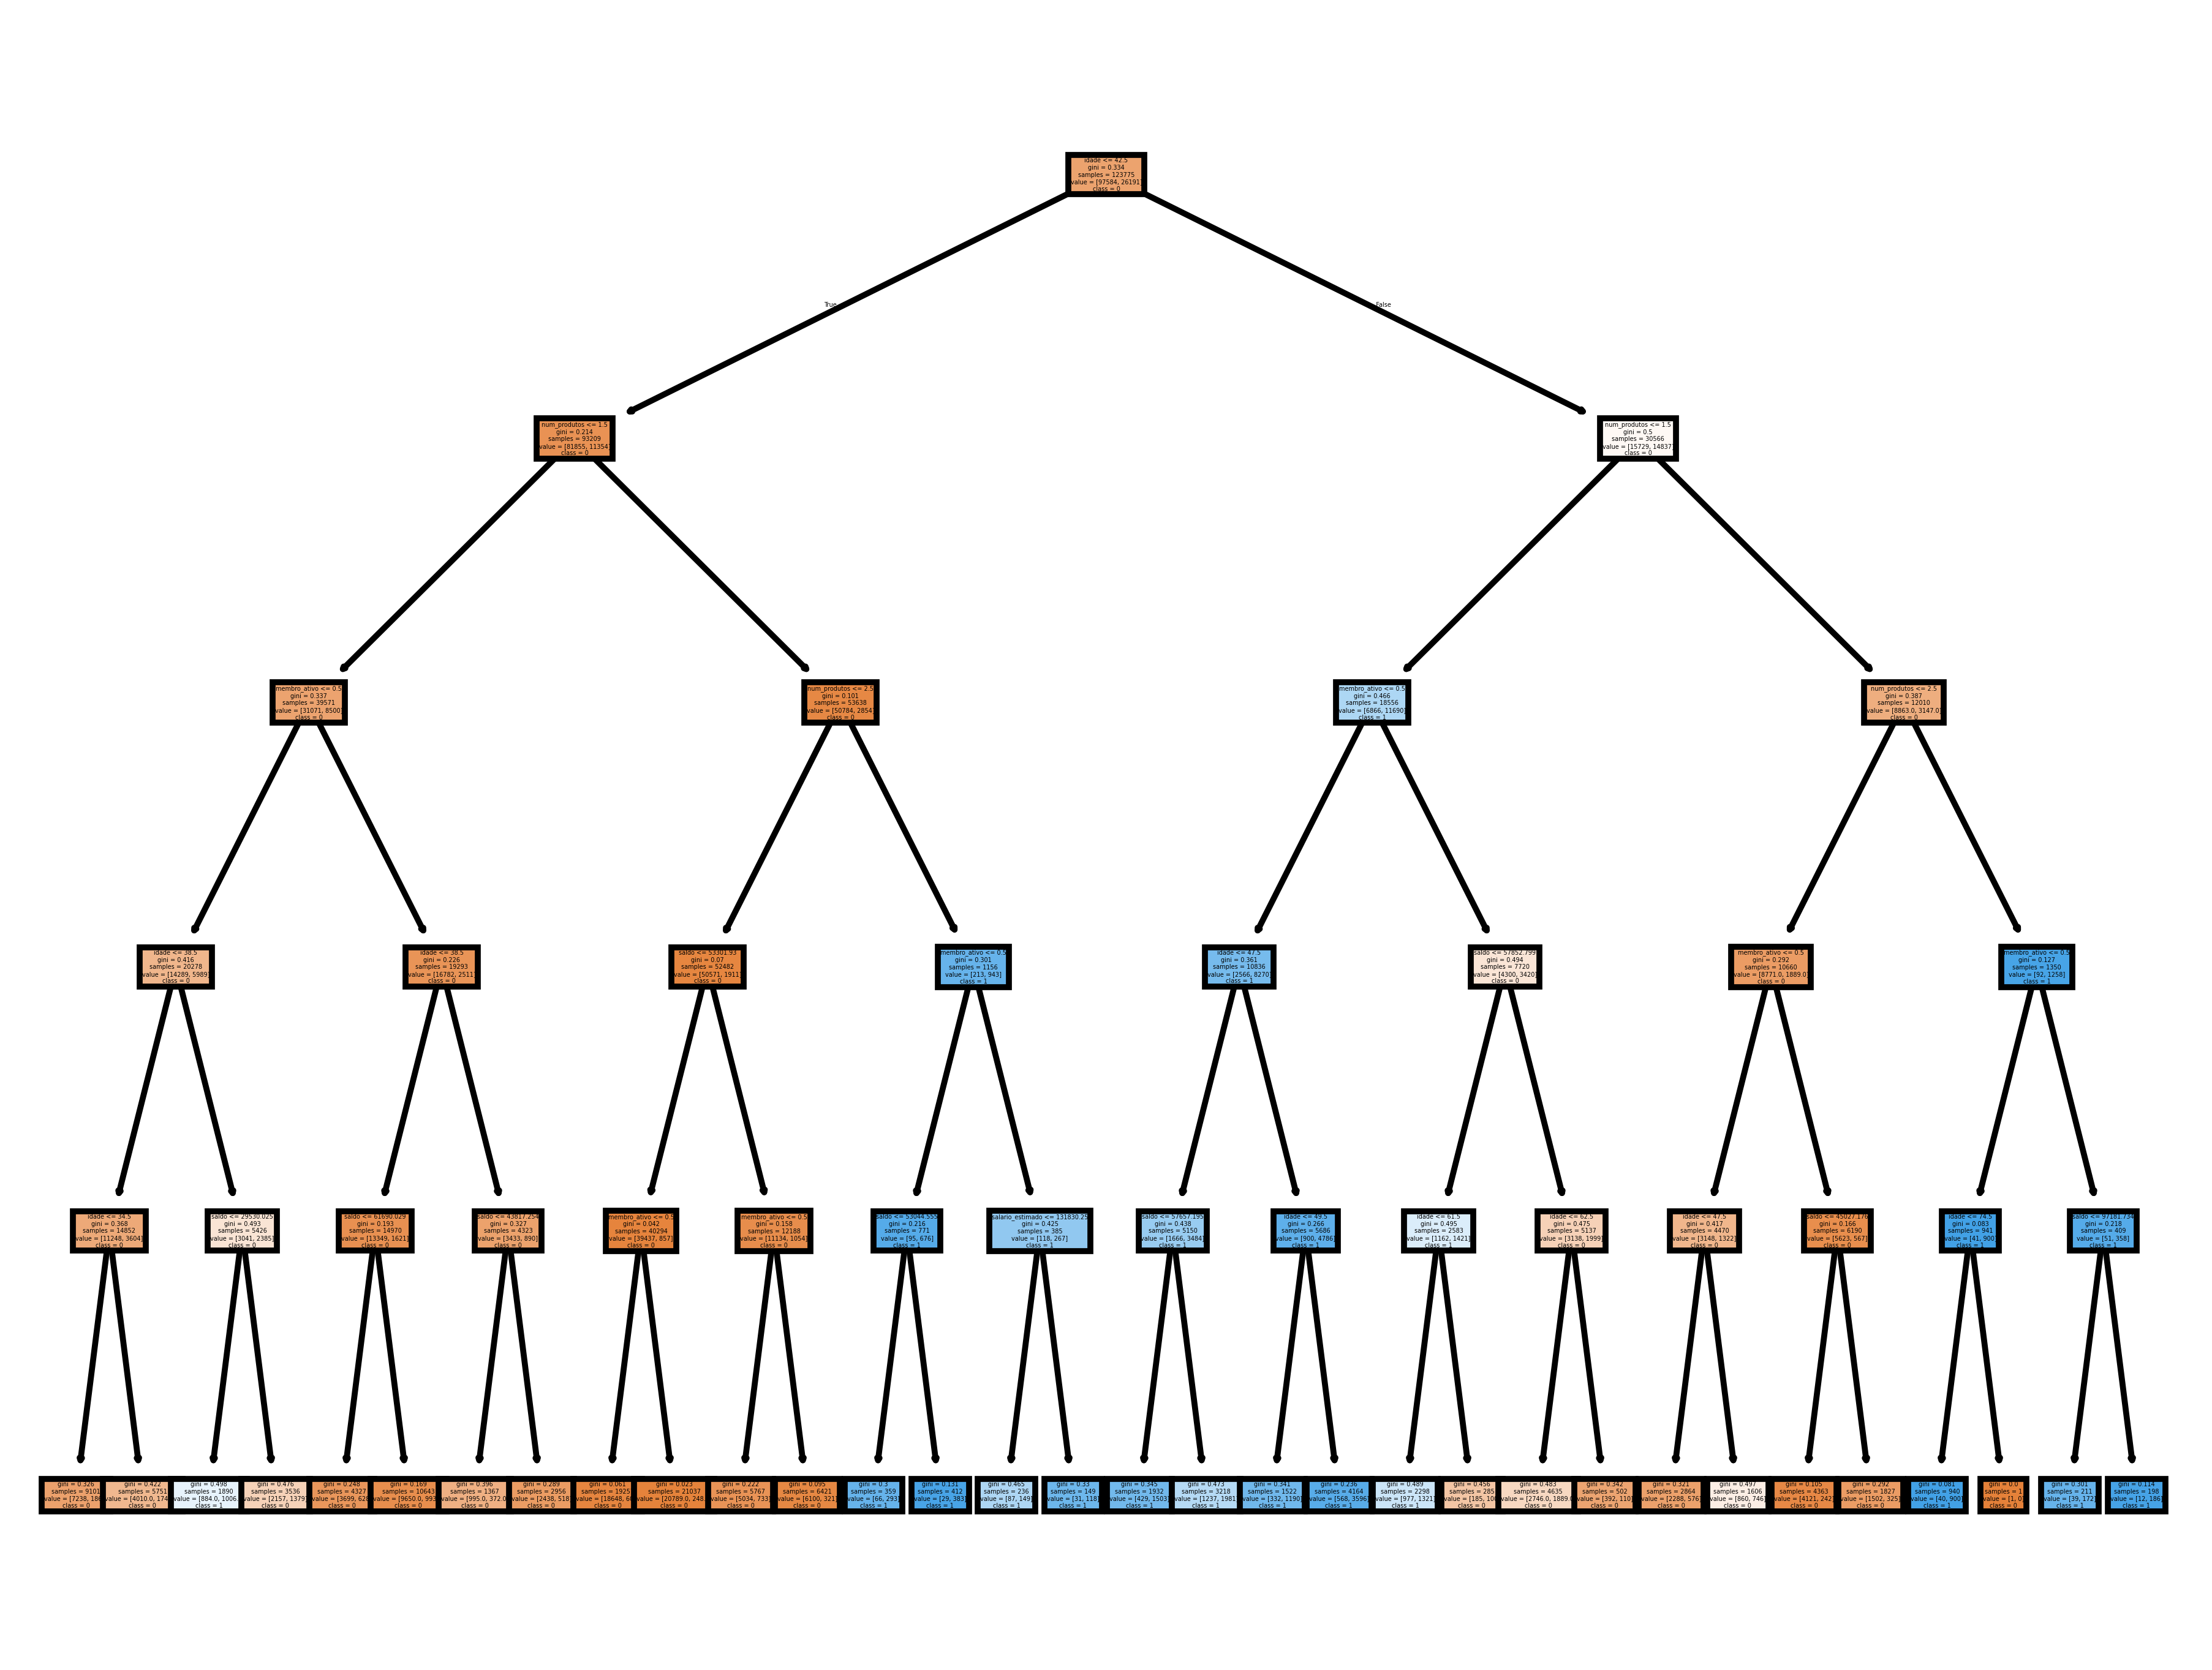

In [42]:
arvore = tree.DecisionTreeClassifier(random_state=42, max_depth=5)
arvore.fit(X_train[feat_num],y_train)

plt.figure(dpi=700)
tree.plot_tree(arvore, feature_names=X_train[feat_num].columns,
               filled=True,
               class_names= [str(i) for i in arvore.classes_])

In [43]:
# Olhando para a importância de cada variável
pd.Series(arvore.feature_importances_, index=X_train[feat_num].columns).sort_values(ascending=False)


,0
idade,0.462264
num_produtos,0.395974
membro_ativo,0.117095
saldo,0.024351
salario_estimado,0.000316
score_credito,0.000000
tempo_relacionamento,0.000000
possui_cartao_credito,0.000000


In [44]:
feature_importances = (pd.Series(arvore.feature_importances_, index=X_train[feat_num].columns)
                       .sort_values(ascending=False)
                       .reset_index())
feature_importances['acumulada'] = feature_importances[0].cumsum()
feature_importances

,index,0,acumulada
0,idade,0.462264,0.462264
1,num_produtos,0.395974,0.858238
2,membro_ativo,0.117095,0.975333
3,saldo,0.024351,0.999684
4,salario_estimado,0.000316,1.000000
5,score_credito,0.000000,1.000000
6,tempo_relacionamento,0.000000,1.000000
7,possui_cartao_credito,0.000000,1.000000


### Categóricas

In [45]:
feat_cat = X_train.select_dtypes(["object"]).columns

df_analise_cat = X_train[feat_cat].copy()
df_analise_cat[target] = y_train

def resumo_categorica(var,df=df_analise_cat, target=target):
    tabela = pd.crosstab(df[var], df[target], normalize='columns')

    resumo = tabela.copy()

    resumo['diff_abs'] = resumo[0] - resumo[1]
    resumo['diff_rel'] = resumo[0] / resumo[1]

    return resumo

In [46]:
resumo_categorica('pais')

churned,0,1,diff_abs,diff_rel
pais,,,,
alemanha,0.164351,0.376923,-0.212573,0.436032
espanha,0.231370,0.177618,0.053752,1.302624
frança,0.604279,0.445458,0.158821,1.356534


In [47]:
resumo_categorica('genero')

churned,0,1,diff_abs,diff_rel
genero,,,,
feminino,0.397627,0.576763,-0.179136,0.689411
masculino,0.602373,0.423237,0.179136,1.423253


In [48]:
from scipy.stats import chi2_contingency

def resumo_categorica_global(var, df=df_analise_cat, target=target):
    # Crosstab absoluta (para chi²)
    tabela_abs = pd.crosstab(df[var], df[target])

    # Crosstab relativa (para diff)
    tabela_rel = pd.crosstab(df[var], df[target], normalize='columns')

    diff_abs = (tabela_rel[0] - tabela_rel[1]).abs().max()
    diff_rel = (tabela_rel[0] / tabela_rel[1]).apply(lambda x: max(x, 1/x)).max()

    chi2, p, _, _ = chi2_contingency(tabela_abs)

    return pd.Series({
        'max_diff_abs': diff_abs,
        'max_diff_rel': diff_rel,
        'chi2': chi2,
        'p_value': p
    })

In [49]:
resumo_final = (
    pd.DataFrame(
        {var: resumo_categorica_global(var) for var in feat_cat}
    )
    .T
    .sort_values('chi2', ascending=False)
)

resumo_final

,max_diff_abs,max_diff_rel,chi2,p_value
pais,0.212573,2.293409,5641.246537,0.0
genero,0.179136,1.450514,2694.562996,0.0


In [50]:
X_cat_ohe = pd.get_dummies(X_train[feat_cat], drop_first=True)

arvore_cat = tree.DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=50
)

arvore_cat.fit(X_cat_ohe, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)

In [51]:
imp_cat = (
    pd.Series(arvore_cat.feature_importances_, index=X_cat_ohe.columns)
    .sort_values(ascending=False)
)

imp_cat_grouped = (
    imp_cat
    .groupby(lambda x: x.rsplit('_')[0])
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

imp_cat_grouped['acumulada'] = imp_cat_grouped[0].cumsum()
imp_cat_grouped

,index,0,acumulada
0,pais,0.669638,0.669638
1,genero,0.330362,1.000000


### Seleção de features

In [52]:
# Selecionando as melhores features das categóricas e das numéricas
best_features_cat = (imp_cat_grouped['index']
                     .tolist())
best_features_num = (feature_importances[feature_importances[0] > 0]['index']
                     .tolist())
best_features = best_features_cat + best_features_num
best_features

['pais',
 'genero',
 'idade',
 'num_produtos',
 'membro_ativo',
 'saldo',
 'salario_estimado']

## Modificação
Fazendo modificações de tratamento, par aumentar a robustez do modelo, normalizar variáveis e evitar enviesamento.

In [53]:
# MODIFY
tree_discretization = discretisation.DecisionTreeDiscretiser(
    variables=best_features_num,
    regression=False,
    bin_output='bin_number',
    cv=3
)

onehot = encoding.OneHotEncoder(
    variables=best_features,
    ignore_format=True,
    drop_last=True
)

# log1p
log1p = transformation.LogCpTransformer(variables=['saldo'],C=1)


## Modelos

## Definindo Hiperparâmetros

Selecionando hiperparâmetros para tunning através do GridSearch, utilizando os modelos:
- LogisticRegression
- RandomForestClassifier
- AdaBoostClassifier
- XGBoostClassifier
- LightGBMClassifier

In [54]:
# MODEL --

params_lr = {
    "max_iter":[50,100,200,500],
    "solver":['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
}

params_rf = {
    "n_estimators":[100,200,500,1000],
    "criterion": ['gini', 'entropy', 'log_loss'],
    #"min_samples_leaf": [15,20,25,30,40,50],
    #"max_depth": [3,6,10,15,20],
    #"class_weight":['balanced','balanced_subsample']
}

params_ada = {
    "n_estimators":[50,100,200,500],
    "learning_rate":[0.01,0.02,0.05,0.10,0.20,0.30]
}

params_xgb = {
    "n_estimators":[50,100,200,500,1000],
    "max_depth": [3,5,10,15,20],
    "learning_rate":[0.01,0.02,0.05,0.10,0.15,0.20,0.30]
}

params_lgbm = {
    "learning_rate":[0.01,0.02,0.05,0.10,0.20,0.30],
    "n_estimators":[50,100,200,500,1000]
}

models = [
    (
        linear_model.LogisticRegression(
            class_weight='balanced',
            random_state=42
        ),
        params_lr
    ),
    (
        ensemble.RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight='balanced',
            max_depth=3,
            min_samples_leaf=15
        ),
        params_rf
    ),
    (
        ensemble.AdaBoostClassifier(
            random_state=42
        ),
        params_ada
    ),
    (
        XGBClassifier(
            random_state=42
        ),
        params_xgb
    ),
    (
        LGBMClassifier(
            random_state=42,
            class_weight='balanced',
            verbose=-1,
            verbosity=-1
        ),
        params_lgbm
    )
]

### Escolhendo o melhor modelo

Aplicando o GridSearch para poder selecionar o modelo que trouxe os melhores resultados.

A escolha é baseado no scoring de recall, que nos retorna o modelo que consegue identificar melhor clientes em risco de dar churn.

In [55]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


fe = FeatureEngineeringTransformer()

pipelines = []          # guarda a pipeline inteira
model_names = []        # identificador

for model, param in models:
    grid = model_selection.GridSearchCV(model,
                                        param,
                                        cv=model_selection.StratifiedKFold(n_splits=5),
                                        scoring='recall',
                                        error_score='raise')

    model_pipeline = pipeline.Pipeline(
        steps=[
            ('feature_engineering', fe),
            ('log', log1p),
            ('Discretizar',tree_discretization),
            ('OneHot',onehot),
            ('Grid',grid)
        ]
    )
    pipelines.append(model_pipeline)
    model_names.append(model.__class__.__name__)

    model_pipeline.fit(X_train[best_features],y_train)

    y_train_predict = model_pipeline.predict(X_train[best_features])
    y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:,1]

    # ASSESS
    acc_train = metrics.accuracy_score(y_train, y_train_predict)
    auc_train = metrics.roc_auc_score(y_train,y_train_proba)
    roc_train = metrics.roc_curve(y_train, y_train_proba)
    recall_train = metrics.recall_score(y_train,y_train_predict)
    f1_train = metrics.f1_score(y_train,y_train_predict)

    model_name = model.__class__.__name__

    print("\n" + "="*80)
    print(f"MODELO: {model_name}")
    print("="*80)

    print("Acurácia Treino:", acc_train)
    print("AUC Treino:",auc_train)
    print("Recall treino:", recall_train)
    print("F1-Score:",f1_train)
    print("\nReport:")
    print(metrics.classification_report(y_train, y_train_predict))

    y_val_predict = model_pipeline.predict(X_val[best_features])
    y_val_proba = model_pipeline.predict_proba(X_val[best_features])[:,1]

    acc_val = metrics.accuracy_score(y_val, y_val_predict)
    auc_val = metrics.roc_auc_score(y_val,y_val_proba)
    roc_val = metrics.roc_curve(y_val, y_val_proba)
    recall_val = metrics.recall_score(y_val,y_val_predict)
    f1_val = metrics.f1_score(y_val,y_val_predict)

    print("\n" + "-"*80)
    print(f"MODELO: {model_name} | Validação")
    print("-"*80)

    print("Acurácia Validação:", acc_val)
    print("AUC Validação:",auc_val)
    print("Recall Validação:", recall_val)
    print("F1-Score:",f1_val)
    print("\nReport:")
    print(metrics.classification_report(y_val, y_val_predict))


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/opt


MODELO: LogisticRegression
Acurácia Treino: 0.7921147242981216
AUC Treino: 0.8725561472314801
Recall treino: 0.7940513916994387
F1-Score: 0.6178091347939101

Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     97584
           1       0.51      0.79      0.62     26191

    accuracy                           0.79    123775
   macro avg       0.72      0.79      0.74    123775
weighted avg       0.84      0.79      0.81    123775


--------------------------------------------------------------------------------
MODELO: LogisticRegression | Validação
--------------------------------------------------------------------------------
Acurácia Validação: 0.7941297656268935
AUC Validação: 0.8713599464353194
Recall Validação: 0.7932416953035509
F1-Score: 0.6198532044396706

Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     32529
           1       0.51      0.79      0.62    

## Visualização dos modelos
Avaliando os modelos visualmente, para entender quais potencialmente seriam os melhores.

In [56]:
from sklearn.metrics import confusion_matrix

# obter probabilidades com fallback
def get_probas(pipe, X):
    """Retorna array de probabilidades da classe positiva.
    Tenta predict_proba, depois decision_function, senão None."""
    try:
        proba = pipe.predict_proba(X)[:, 1]
        return proba
    except Exception:
        try:
            df = pipe.decision_function(X)
            # se decision_function retornar shape (n_samples, ), normaliza para [0,1]
            # usando min-max para permitir plotting de ROC/PR
            df_min, df_max = df.min(), df.max()
            if df_max == df_min:
                return np.zeros_like(df)
            return (df - df_min) / (df_max - df_min)
        except Exception:
            return None

In [57]:
# Coletar métricas por modelo (treino e Validação)
records = []
roc_curves = {}
pr_curves = {}

for i, pipe in enumerate(pipelines):
    name = model_names[i]
    # probabilidades
    proba_train = get_probas(pipe, X_train[best_features])
    proba_val  = get_probas(pipe, X_val[best_features])

    # pular modelos que não suportam probas
    if proba_train is None or proba_val is None:
        print(f"Pulando {name}: não tem probabilidade/decision_function disponível.")
        continue

    # predições
    y_train_pred = pipe.predict(X_train[best_features])
    y_val_pred  = pipe.predict(X_val[best_features])

    # ROC / AUC
    fpr_train, tpr_train, _ = metrics.roc_curve(y_train, proba_train)
    auc_train = metrics.roc_auc_score(y_train, proba_train)

    fpr_val, tpr_val, _ = metrics.roc_curve(y_val, proba_val)
    auc_val = metrics.roc_auc_score(y_val, proba_val)

    # Precision / Recall / F1 / Accuracy (Validação e Treino)
    prec_train = metrics.precision_score(y_train, y_train_pred, zero_division=0)
    rec_train  = metrics.recall_score(y_train, y_train_pred, zero_division=0)
    f1_train   = metrics.f1_score(y_train, y_train_pred, zero_division=0)
    acc_train  = metrics.accuracy_score(y_train, y_train_pred)

    prec_val = metrics.precision_score(y_val, y_val_pred, zero_division=0)
    rec_val  = metrics.recall_score(y_val, y_val_pred, zero_division=0)
    f1_val   = metrics.f1_score(y_val, y_val_pred, zero_division=0)
    acc_val  = metrics.accuracy_score(y_val, y_val_pred)

    # Precision-Recall curve (Validação)
    precision, recall, _ = metrics.precision_recall_curve(y_val, proba_val)
    pr_auc = metrics.auc(recall, precision)

    # confusion matrix (Validação)
    cm = confusion_matrix(y_val, y_val_pred)

    # guardar
    records.append({
        "model": name,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "precision_train": prec_train,
        "precision_val": prec_val,
        "recall_train": rec_train,
        "recall_val": rec_val,
        "f1_train": f1_train,
        "f1_val": f1_val,
        "accuracy_train": acc_train,
        "accuracy_val": acc_val,
        "pr_auc_val": pr_auc,
        "cm_val": cm
    })

    roc_curves[name] = {"train": (fpr_train, tpr_train), "validacao": (fpr_val, tpr_val)}
    pr_curves[name] = {"precision": precision, "recall": recall}

# transformar em DataFrame (apenas métricas numéricas)
metrics_df = pd.DataFrame(records).set_index("model").sort_index()
# mostrar tabela resumida
print(metrics_df[["auc_val","precision_val","recall_val","f1_val","accuracy_val","pr_auc_val"]])


                         auc_val  precision_val  recall_val    f1_val  \
model                                                                   
AdaBoostClassifier      0.881278       0.756445    0.510882  0.609873   
LGBMClassifier          0.887515       0.548763    0.782474  0.645103   
LogisticRegression      0.871360       0.508668    0.793242  0.619853   
RandomForestClassifier  0.864921       0.428655    0.835166  0.566533   
XGBClassifier           0.887679       0.744843    0.558419  0.638298   

                        accuracy_val  pr_auc_val  
model                                             
AdaBoostClassifier          0.861703    0.715893  
LGBMClassifier              0.817834    0.725837  
LogisticRegression          0.794130    0.693613  
RandomForestClassifier      0.729586    0.679831  
XGBClassifier               0.866090    0.726425  


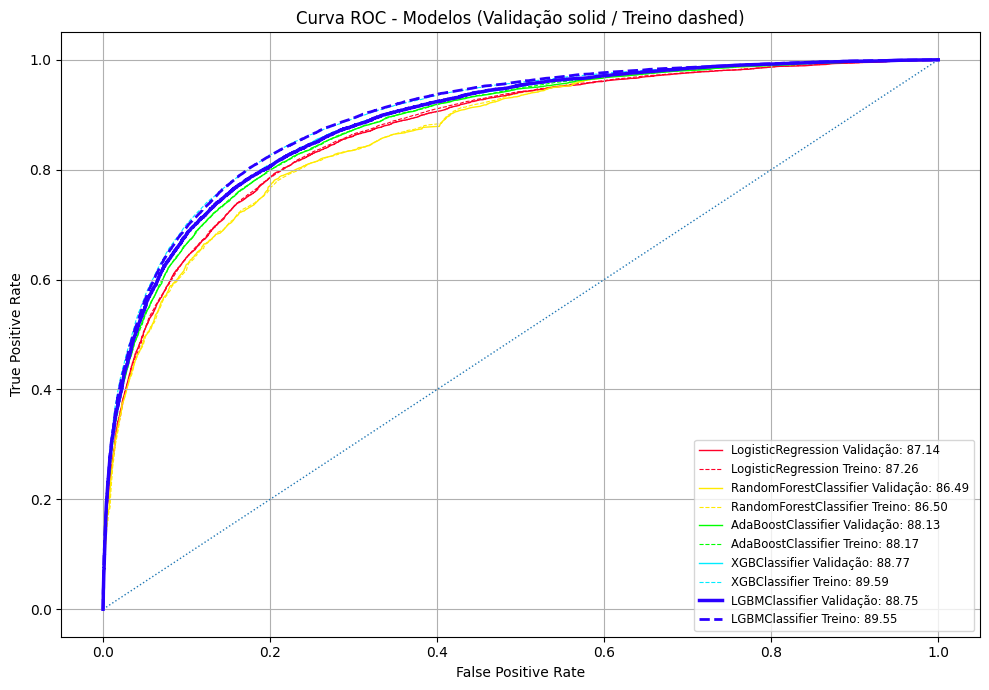

In [82]:
lgbm_name = None
for n in metrics_df.index:
    if "LGBM" in n or "LightGBM" in n or "lgbm" in n.lower() or "lightgbm" in n.lower():
        lgbm_name = n
        break

# Curvas ROC
plt.figure(figsize=(10, 7))
cmap = plt.get_cmap('gist_rainbow')

for i, (name, curves) in enumerate(roc_curves.items()):

    cor_mapeada = cmap(i/len(roc_curves))

    fpr_t, tpr_t = curves["validacao"]
    fpr_tr, tpr_tr = curves["train"]

    if name == lgbm_name:
        plt.plot(fpr_t, tpr_t, linestyle='-', linewidth=2.5,
                 label=f"{name} Validação: {100*metrics_df.loc[name,'auc_val']:.2f}", zorder=5, color=cor_mapeada)
        plt.plot(fpr_tr, tpr_tr, linestyle='--', linewidth=2.0,
                 label=f"{name} Treino: {100*metrics_df.loc[name,'auc_train']:.2f}", zorder=4, color=cor_mapeada)
    else:
        plt.plot(fpr_t, tpr_t, linestyle='-', linewidth=1,
                 label=f"{name} Validação: {100*metrics_df.loc[name,'auc_val']:.2f}", zorder=1, color=cor_mapeada)
        plt.plot(fpr_tr, tpr_tr, linestyle='--', linewidth=0.8,
                 label=f"{name} Treino: {100*metrics_df.loc[name,'auc_train']:.2f}", zorder=0, color=cor_mapeada)

plt.plot([0,1],[0,1], linestyle=':', linewidth=1)
plt.grid(True)
plt.title("Curva ROC - Modelos (Validação solid / Treino dashed)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

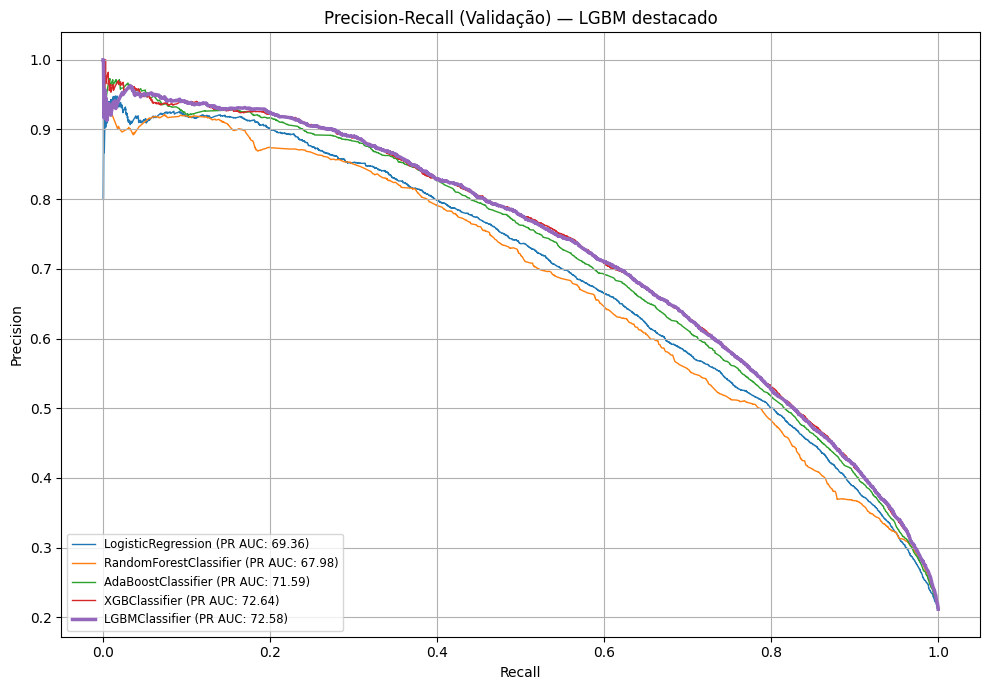

In [61]:
# Precision-Recall curves (Validação)
plt.figure(figsize=(10, 7))
for name, pr in pr_curves.items():
    precision = pr["precision"]
    recall = pr["recall"]
    if name == lgbm_name:
        plt.plot(recall, precision, linestyle='-', linewidth=2.5,
                 label=f"{name} (PR AUC: {100*metrics_df.loc[name,'pr_auc_val']:.2f})", zorder=5)
    else:
        plt.plot(recall, precision, linestyle='-', linewidth=1,
                 label=f"{name} (PR AUC: {100*metrics_df.loc[name,'pr_auc_val']:.2f})", zorder=1)

plt.grid(True)
plt.title("Precision-Recall (Validação) — LGBM destacado")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left', fontsize='small')
plt.tight_layout()
plt.show()


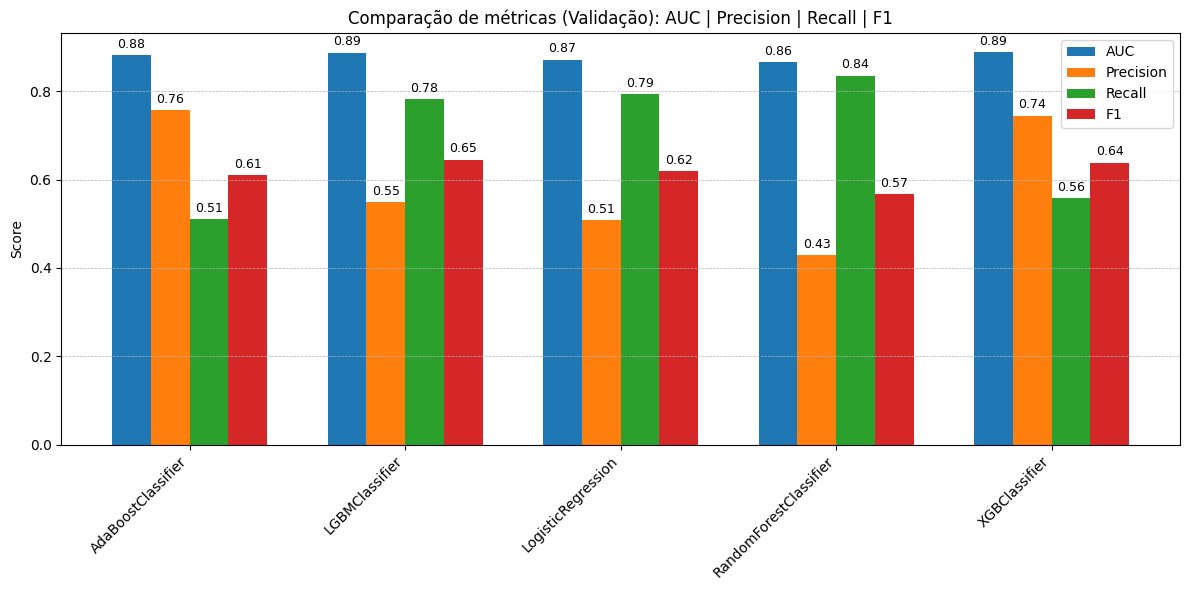

In [62]:
# Barra comparativa (métricas de interesse na Validação)
# Selecionar as colunas que queremos comparar
cmp_metrics = metrics_df[["auc_val","precision_val","recall_val","f1_val"]].copy()
# renomear colunas para rótulos mais curtos
cmp_metrics.columns = ["AUC","Precision","Recall","F1"]

labels = cmp_metrics.index.tolist()
x = np.arange(len(labels))
width = 0.18

plt.figure(figsize=(12, 6))
for j, col in enumerate(cmp_metrics.columns):
    vals = cmp_metrics[col].values
    bars = plt.bar(
        x + (j - 1.5) * width,
        vals,
        width,
        label=col
    )

    plt.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Comparação de métricas (Validação): AUC | Precision | Recall | F1")
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

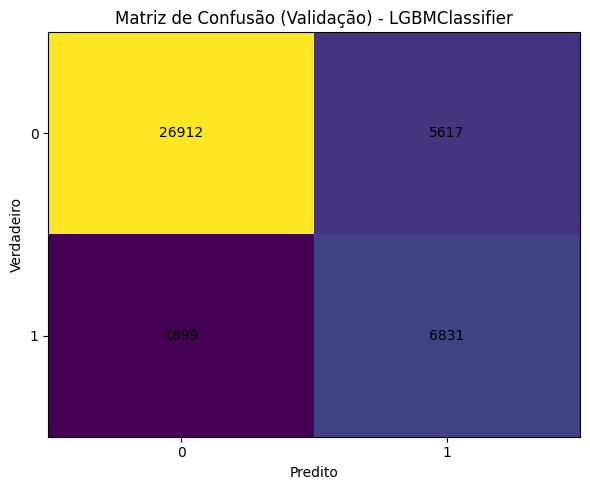

In [63]:
# Matriz de confusão (Validação) -- LGBM
if lgbm_name is not None:
    cm = metrics_df.loc[lgbm_name,"cm_val"]
    # plota cm com imshow e anotações
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest', aspect='auto')
    plt.title(f"Matriz de Confusão (Validação) - {lgbm_name}")
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    # anota os valores no mapa
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.xticks([0,1])
    plt.yticks([0,1])
    plt.tight_layout()
    plt.show()
else:
    print("LGBM não encontrado nos nomes dos modelos")

## Serialização do melhor modelo de LightGBM Classifier
Nos testes, LGBM não só obteve um bom desempenho na pontuação de recall, identificando clientes de risco, como também pontuou melhor em precisão em relação aos outros modelos. Pela curva ROC também percebemos que ele é melhor em discriminar positivos/negativos; além de demonstrar mais consistência entre a base de treino e teste. Portanto foi escolhido como o modelo final para o projeto.


In [64]:
lgbm_pipeline = pipelines[model_names.index('LGBMClassifier')]

lgbm_best_estimator = lgbm_pipeline.named_steps['Grid'].best_estimator_

joblib.dump(lgbm_pipeline, "./model_pipeline.joblib")

['./model_pipeline.joblib']

## Aplicando o Modelo Serializado

Com modelo serializado podemos usa-lo em outras bases

In [65]:
model = joblib.load("./model_pipeline.joblib")

In [66]:
df = pd.read_csv("https://raw.githubusercontent.com/hackathon-ficaAi/churnInsight/refs/heads/main/data/churn_teste.csv")
features = model.feature_names_in_
amostra = df[features].head(10).copy()
amostra

,pais,genero,idade,num_produtos,membro_ativo,saldo,salario_estimado
0,frança,feminino,23.0,2,1.0,0.00,160976.75
1,frança,feminino,46.0,1,0.0,0.00,72549.27
2,frança,feminino,34.0,2,0.0,0.00,138882.09
3,frança,masculino,36.0,1,0.0,0.00,113931.57
4,alemanha,masculino,38.0,1,0.0,121263.62,139431.00
5,frança,feminino,22.0,2,0.0,0.00,51907.72
6,espanha,masculino,45.0,2,1.0,0.00,157878.67
7,espanha,feminino,47.0,2,1.0,0.00,126784.29
8,frança,feminino,47.0,1,0.0,111096.91,94978.10
9,espanha,masculino,30.0,2,1.0,0.00,149195.44


In [67]:
predicao = model.predict_proba(amostra[features])[:,1]
amostra['proba'] = predicao
amostra

,pais,genero,idade,num_produtos,membro_ativo,saldo,salario_estimado,proba
0,frança,feminino,23.0,2,1.0,0.00,160976.75,0.076404
1,frança,feminino,46.0,1,0.0,0.00,72549.27,0.950655
2,frança,feminino,34.0,2,0.0,0.00,138882.09,0.079529
3,frança,masculino,36.0,1,0.0,0.00,113931.57,0.601493
4,alemanha,masculino,38.0,1,0.0,121263.62,139431.00,0.731916
5,frança,feminino,22.0,2,0.0,0.00,51907.72,0.181148
6,espanha,masculino,45.0,2,1.0,0.00,157878.67,0.124478
7,espanha,feminino,47.0,2,1.0,0.00,126784.29,0.238236
8,frança,feminino,47.0,1,0.0,111096.91,94978.10,0.827506
9,espanha,masculino,30.0,2,1.0,0.00,149195.44,0.024522


📋 RELATÓRIO FINAL DE ANÁLISE DE CHURN

📌 RESUMO EXECUTIVO:
• Total de clientes analisados: 165,034
• Taxa de churn atual: 21.16%
• Melhor modelo: LGBMClassifier
• F1-Score do modelo: 0.6451
• Clientes com churn identificados corretamente: 78.2%

🔍 PRINCIPAIS INSIGHTS DO DATASET:
1. Clientes com apenas 1 produto têm maior risco
2. Clientes inativos têm risco significativamente maior
3. Cliente mais velho tem maior risco

🎯 RECOMENDAÇÕES DE AÇÃO PARA REDUÇÃO DE CHURN:
1. PROGRAMA DE RETENÇÃO PROATIVA:
   • Implementar sistema de alerta para clientes de alto risco
   • Contato proativo 30 dias antes do churn previsto
   • Ofertas personalizadas baseadas no perfil do cliente

2. ENGARAJAMENTO DE CLIENTES INATIVOS:
   • Campanha de reativação para membros inativos
   • Benefícios exclusivos para reengajamento
   • Notificações personalizadas e conteúdo relevante

3. CROSS-SELLING E UP-SELLING:
   • Incentivar contratação do 2º produto (maior retenção)
   • Bundles de produtos com descontos
   • Programa 'cliente multiconta' com benefícios progressivos

4. SEGMENTAÇÃO POR SALDO:
   • Programa para incentivar saldo mínimo
   • Taxas reduzidas para clientes com saldo alto
   • Alertas para clientes com saldo próximo de zero

5. PERSONALIZAÇÃO POR PERFIL:
   • Estratégias diferentes por faixa etária
   • Comunicação adaptada por país/cultura
   • Produtos segmentados por poder aquisitivo

6. MELHORIA NA EXPERIÊNCIA:
   • Simplificação de processos e burocracia
   • Atendimento premium para clientes de alto valor
   • Resolução rápida de problemas e reclamações

7. PROGRAMA DE FIDELIDADE:
   • Pontos por uso de serviços
   • Descontos progressivos por tempo de conta
   • Benefícios exclusivos por nível de fidelidade

8. MONITORAMENTO CONTÍNUO:
   • Dashboard em tempo real de indicadores de churn
   • Alertas automáticos para comportamentos de risco
   • Análise mensal de tendências e eficácia das ações

💰 ESTIMATIVA DE IMPACTO ECONÔMICO:
• Clientes totais: 165,034
• Clientes com churn atual: 34,921
• Perda anual estimada: R$ 17,460,500.00

• Com o modelo (Recall: 78.2%):
  • Clientes de churn identificados: 27,324
  • Clientes potencialmente salvos (30% efetividade): 8,197
  • Economia anual estimada: R$ 4,098,500.00
  • ROI potencial (custo modelo vs economia): 409.9x

🚀 PRÓXIMOS PASSOS PARA IMPLEMENTAÇÃO:
1. IMPLEMENTAÇÃO DO MODELO EM PRODUÇÃO:
   • Integrar modelo com sistema CRM
   • Criar API para previsões em tempo real
   • Desenvolver dashboard de monitoramento

2. TESTE PILOTO:
   • Selecionar segmento para teste (ex: 10% dos clientes)
   • Implementar ações de retenção baseadas no modelo
   • Medir resultados após 3-6 meses

3. MONITORAMENTO CONTÍNUO:
   • Acompanhar métricas de performance do modelo
   • Re-treinar modelo periodicamente (ex: mensalmente)
   • Ajustar ações baseado em feedback e resultados

4. EXPANSÃO:
   • Aplicar modelo para todos os clientes
   • Desenvolver modelos específicos por segmento
   • Integrar com outros sistemas (marketing, atendimento)

5. CULTURA DATA-DRIVEN:
   • Treinar equipes para usar insights do modelo
   • Criar processos baseados em dados
   • Incentivar decisões baseadas em evidências